# BTC Price Forecasting
## Model Training and Evaluation

This notebook builds, trains and evaluates the LSTM model.
Preprocessing is complete this notebook loads the scaled arrays
produced in preprocessing and focuses entirely on the model.

**Input files read from Drive:**
- `train_scaled.npy`, `val_scaled.npy`, `test_scaled.npy`
- `scaler.pkl`

**Output files written to Drive:**
- `model.keras`  best model weights saved during training
- `predictions.npy` test set predictions for analysis

**Architecture:**
- Input: (1440, 6) 24 hours × 6 features
- LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.2) → Dense(1)
- Loss: Mean Squared Error
- Optimizer: Adam

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import pickle
import os

DRIVE_PATH  = '/content/drive/MyDrive/BitcoinProject/'
WINDOW_SIZE = 1440
HORIZON     = 1
BATCH_SIZE  = 32
LEARNING_RATE = 0.0005
CLOSE_IDX   = 0

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

Mounted at /content/drive
TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


##  Loading Preprocessed Data

In [2]:
train_scaled = np.load(DRIVE_PATH + 'train_scaled.npy')
val_scaled   = np.load(DRIVE_PATH + 'val_scaled.npy')
test_scaled  = np.load(DRIVE_PATH + 'test_scaled.npy')

with open(DRIVE_PATH + 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print(f'  train_scaled : {train_scaled.shape}')
print(f'  val_scaled   : {val_scaled.shape}')
print(f'  test_scaled  : {test_scaled.shape}')
print(f'  Scaler feature range (Close): '
      f'[{scaler.data_min_[CLOSE_IDX]:.2f}, {scaler.data_max_[CLOSE_IDX]:.2f}] USD')
print('Data loaded ')

  train_scaled : (698400, 6)
  val_scaled   : (44640, 6)
  test_scaled  : (87840, 6)
  Scaler feature range (Close): [0.06, 19891.99] USD
Data loaded 


## Building tf.data Pipelines

Rather than materialising millions of windows as NumPy arrays in RAM,
`tf.data.Dataset` streams windows one batch at a time directly from the
scaled arrays. Only the current batch is ever held in memory.

Each pipeline slides a window of 1,440 + 1 rows across the data and produces:
- **X** the first 1,440 rows (24 hours of features)
- **y** the Close value at the very next row (1 minute ahead)

Training data is shuffled. Validation and test preserve time order.
A `shift=60` stride yields one window per hour, keeping memory usage manageable.

In [3]:
def make_dataset(data, shuffle=False):
    total_length = WINDOW_SIZE + HORIZON
    ds = tf.data.Dataset.from_tensor_slices(data)
    ds = ds.window(total_length, shift=5, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(total_length, drop_remainder=True))
    ds = ds.map(
        lambda w: (w[:WINDOW_SIZE], w[WINDOW_SIZE + HORIZON - 1, CLOSE_IDX]),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_scaled, shuffle=True)
val_ds   = make_dataset(val_scaled,   shuffle=False)
test_ds  = make_dataset(test_scaled,  shuffle=False)

for name, ds in [('train_ds', train_ds), ('val_ds', val_ds), ('test_ds', test_ds)]:
    for X_batch, y_batch in ds.take(1):
        print(f'  {name}  X: {X_batch.shape}  y: {y_batch.shape}')

print('Pipelines ready ')

  train_ds  X: (32, 1440, 6)  y: (32,)
  val_ds  X: (32, 1440, 6)  y: (32,)
  test_ds  X: (32, 1440, 6)  y: (32,)
Pipelines ready 


## Define the Model

A stacked LSTM architecture with Dropout regularisation. The first LSTM layer
returns the full sequence so the second layer can learn higher-level temporal
patterns. Dropout between layers reduces overfitting.

| Layer | Output shape | Parameters |
|-------|-------------|------------|
| Input | (1440, 6) | — |
| LSTM(64) | (1440, 64) | 18,176 |
| Dropout(0.2) | (1440, 64) | — |
| LSTM(32) | (32,) | 12,416 |
| Dropout(0.2) | (32,) | — |
| Dense(1) | (1,) | 33 |

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

model = Sequential([
    Input(shape=(WINDOW_SIZE, train_scaled.shape[1])),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.1),
    Dense(1)
])

model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=['mae']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1440, 128)      │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1440, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1440, 64)       │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1440, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,977 (511.63 KB)

 Trainable params: 130,977 (511.63 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Model

Two callbacks are used during training:

- **EarlyStopping** halts training if validation loss stops improving and
  automatically restores the best weights
- **ModelCheckpoint** saves the best model to Drive after each epoch,
  ensuring no progress is lost if the session disconnects

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model_path = DRIVE_PATH + 'model.keras'

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=model_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks,
    verbose=1
)

print('Training complete ')

Epoch 1/12
   4356/Unknown 542s 123ms/step - loss: 1.7970e-04 - mae: 0.0083

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.00001, saving model to /content/drive/MyDrive/BitcoinProject/model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/BitcoinProject/model.keras
4356/4356 ━━━━━━━━━━━━━━━━━━━━ 556s 126ms/step - loss: 2.9401e-04 - mae: 0.0109 - val_loss: 1.0086e-05 - val_mae: 0.0026 - learning_rate: 5.0000e-04
Epoch 2/12
4356/4356 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 2.0395e-04 - mae: 0.0100
Epoch 2: val_loss improved from 0.00001 to 0.00001, saving model to /content/drive/MyDrive/BitcoinProject/model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/BitcoinProject/model.keras
4356/4356 ━━━━━━━━━━━━━━━━━━━━ 552s 126ms/step - loss: 2.3089e-04 - mae: 0.0097 - val_loss: 8.3617e-06 - val_mae: 0.0024 - learning_rate: 5.0000e-04
Epoch 3/12
4356/4356 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 2.3981e-04 - mae: 0.0110
Epoch 3: val_loss improved from 0.00001 to 0.00001, saving model to /content/drive/MyDrive/BitcoinProject/model.keras

E

## Training History

Loss curves show whether the model learned without overfitting.
A well-trained model has validation loss tracking closely with training loss
throughout, with no significant divergence.

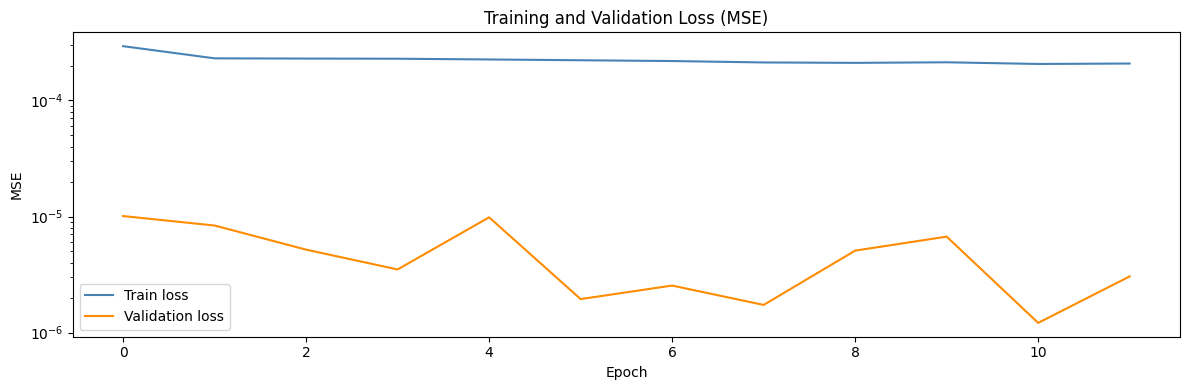

  Best epoch     : 11
  Best val loss  : 1.21e-06


In [9]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(history.history['loss'],     label='Train loss',      color='steelblue')
ax.plot(history.history['val_loss'], label='Validation loss', color='darkorange')
ax.set_title('Training and Validation Loss (MSE)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

best_epoch    = np.argmin(history.history['val_loss'])
best_val_loss = history.history['val_loss'][best_epoch]
print(f'  Best epoch     : {best_epoch + 1}')
print(f'  Best val loss  : {best_val_loss:.2e}')

## Evaluation on Test Set

The model is evaluated on the held-out test set data it has never seen
during training or validation. Predictions are inverse-transformed from
scaled values back to USD for interpretability.

In [10]:
test_loss, test_mae = model.evaluate(test_ds, verbose=0)
print(f'  Test MSE : {test_loss:.6f}')
print(f'  Test MAE : {test_mae:.6f}')

y_pred   = model.predict(test_ds, verbose=0).flatten()
y_actual = np.concatenate([y for _, y in test_ds])

dummy_pred   = np.zeros((len(y_pred),   train_scaled.shape[1]))
dummy_actual = np.zeros((len(y_actual), train_scaled.shape[1]))
dummy_pred[:,   CLOSE_IDX] = y_pred
dummy_actual[:, CLOSE_IDX] = y_actual

y_pred_usd   = scaler.inverse_transform(dummy_pred)[:,   CLOSE_IDX]
y_actual_usd = scaler.inverse_transform(dummy_actual)[:, CLOSE_IDX]

errors = y_pred_usd - y_actual_usd
print(f'  Mean error : ${errors.mean():.2f}')
print(f'  MAE (USD)  : ${np.abs(errors).mean():.2f}')
print(f'  Std error  : ${errors.std():.2f}')
print(f'  Actual mean price     : ${y_actual_usd.mean():.2f}')
print(f'  Predicted mean price  : ${y_pred_usd.mean():.2f}')

  Test MSE : 0.000006
  Test MAE : 0.001932
  Mean error : $31.16
  MAE (USD)  : $38.44
  Std error  : $36.45
  Actual mean price     : $6933.35
  Predicted mean price  : $6964.52


## Actual vs Predicted

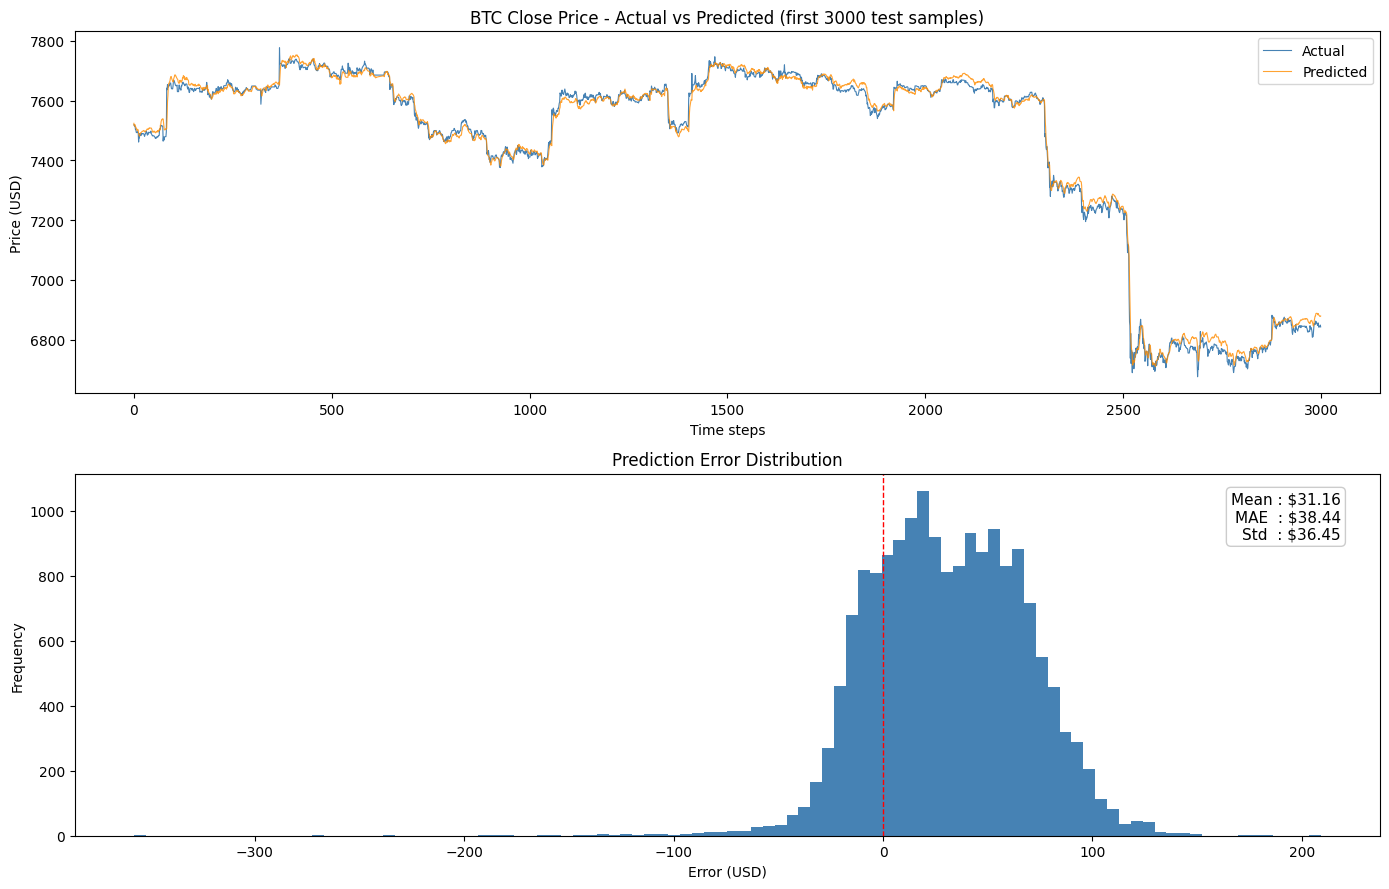

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

n_plot = 3000
axes[0].plot(y_actual_usd[:n_plot], label='Actual',
             color='steelblue', linewidth=0.8)
axes[0].plot(y_pred_usd[:n_plot],   label='Predicted',
             color='darkorange', linewidth=0.8, alpha=0.8)
axes[0].set_title(f'BTC Close Price - Actual vs Predicted (first {n_plot} test samples)')
axes[0].set_xlabel('Time steps')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

axes[1].hist(errors, bins=100, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Prediction Error Distribution')
axes[1].set_xlabel('Error (USD)')
axes[1].set_ylabel('Frequency')
axes[1].text(
    0.97, 0.95,
    f'Mean : ${errors.mean():.2f}\nMAE  : ${np.abs(errors).mean():.2f}\nStd  : ${errors.std():.2f}',
    transform=axes[1].transAxes, ha='right', va='top', fontsize=11,
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='#cccccc')
)

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'predictions.png', dpi=150, bbox_inches='tight')
plt.show()

##  Scatter Plot: Actual vs Predicted

A perfect model produces a straight diagonal line. Deviation from the diagonal
reveals systematic bias consistent over or under-prediction at specific
price levels.

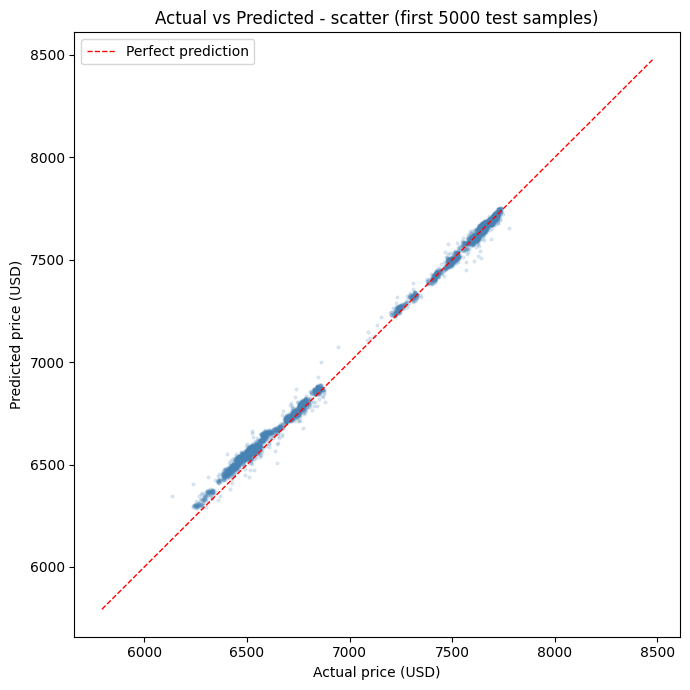

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_actual_usd[:5000], y_pred_usd[:5000],
           alpha=0.15, s=4, color='steelblue')

lims = [min(y_actual_usd.min(), y_pred_usd.min()),
        max(y_actual_usd.max(), y_pred_usd.max())]
ax.plot(lims, lims, color='red', linewidth=1, linestyle='--', label='Perfect prediction')
ax.set_title('Actual vs Predicted - scatter (first 5000 test samples)')
ax.set_xlabel('Actual price (USD)')
ax.set_ylabel('Predicted price (USD)')
ax.legend()

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Saving Predictions

In [13]:
np.save(DRIVE_PATH + 'predictions.npy', y_pred_usd)
np.save(DRIVE_PATH + 'actuals.npy',     y_actual_usd)

print(f'  predictions.npy saved  ({len(y_pred_usd):,} values)')
print(f'  actuals.npy saved      ({len(y_actual_usd):,} values)')
print()
print('=' * 50)
print('   FINAL RESULTS SUMMARY')
print('=' * 50)
print(f'  Dataset       : Coinbase BTC/USD 1-min')
print(f'  Training data : 2017-01-01 → 2018-05-01')
print(f'  Window size   : {WINDOW_SIZE} steps (24 hours)')
print(f'  Horizon       : {HORIZON} step (1 minute ahead)')
print(f'  Features      : Close, volume_log, hour/dow sin/cos')
print(f'  Architecture  : LSTM(64) → Dropout → LSTM(32) → Dropout → Dense(1)')
print(f'  Test MSE      : {test_loss:.2e}')
print(f'  Test MAE USD  : ${np.abs(errors).mean():.2f}')
print(f'  Mean error    : ${errors.mean():.2f}')
print('=' * 50)

  predictions.npy saved  (17,280 values)
  actuals.npy saved      (17,280 values)

   FINAL RESULTS SUMMARY
  Dataset       : Coinbase BTC/USD 1-min
  Training data : 2017-01-01 → 2018-05-01
  Window size   : 1440 steps (24 hours)
  Horizon       : 1 step (1 minute ahead)
  Features      : Close, volume_log, hour/dow sin/cos
  Architecture  : LSTM(64) → Dropout → LSTM(32) → Dropout → Dense(1)
  Test MSE      : 5.81e-06
  Test MAE USD  : $38.44
  Mean error    : $31.16
